In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

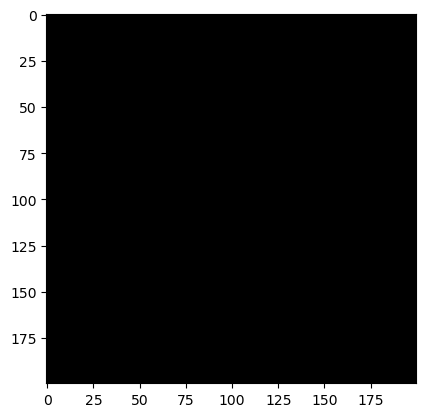

In [3]:
img1 = np.zeros((200, 200, 3))
plt.imshow(img1)
plt.show()

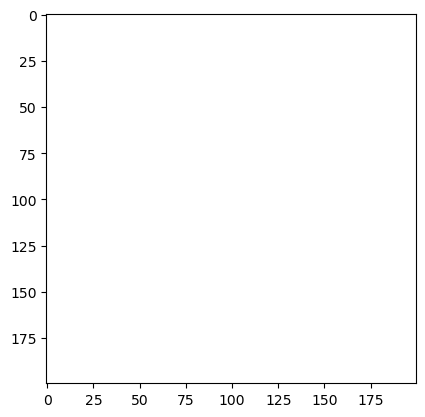

In [4]:
img2 = torch.full(size=(200, 200, 3), fill_value=255)
plt.imshow(img2)
plt.show()

torch.Size([4, 368, 459])


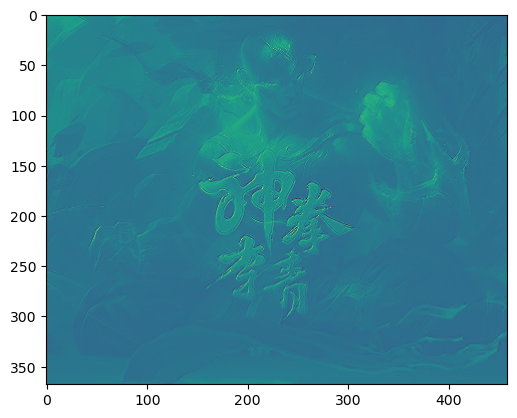

In [20]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

img = plt.imread('./data/a.jpg')
# print(img, img.shape)
# print('*' * 50)

img = torch.tensor(img, dtype=torch.float32)
img = img.permute(2, 0, 1)
# print(img, img.shape)

img = img.unsqueeze(0)
# print(img.shape)

conv2d = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, stride=2, padding=0)
feature_map = conv2d(img)
# print(feature_map, feature_map.shape)
print(feature_map[0].shape)

feature_map = feature_map[0].permute(1, 2, 0)
feature1 = feature_map[:, :, 0].detach().numpy()
plt.imshow(feature1)
plt.show()

In [ ]:
inputs = torch.tensor([[[0, 1, 2], [3, 4, 5], [6, 7, 8]]])
print(inputs.shape)

pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=0)
outputs = pool1(inputs)
print(outputs.shape)

pool2 = nn.AvgPool2d(kernel_size=2, stride=1, padding=0)
outputs = pool2(inputs)
print(outputs.shape)


torch.Size([1, 3, 3])
torch.Size([1, 2, 2])
torch.Size([1, 2, 2])
torch.Size([3, 3, 3])


In [27]:
inputs = torch.tensor([
    [[0, 1, 2], [3, 4, 5], [6, 7, 8]],
    [[10, 20, 30], [40, 50, 60], [70, 80, 90]],
    [[11, 22, 33], [44, 55, 66], [77, 88, 99]]
])
print(inputs.shape)

pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=0)
outputs = pool1(inputs)
print(outputs.shape)

pool2 = nn.AvgPool2d(kernel_size=2, stride=1, padding=0)
outputs = pool2(inputs)
print(outputs.shape)

torch.Size([3, 3, 3])
torch.Size([3, 2, 2])
torch.Size([3, 2, 2])


/Users/yiseungkim/Project_settings/miniconda3/envs/ml_notes/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000, 32, 32, 3) (10000, 32, 32, 3)
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


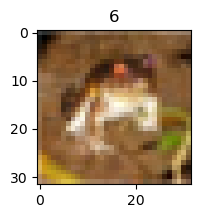

In [43]:
# cifar10 图像分类案例

import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchsummary import summary

BATCH_SIZE = 8

train_data = CIFAR10(root='./data', train=True, transform=ToTensor(), download=False)
test_data = CIFAR10(root='./data', train=False, transform=ToTensor(), download=False)

print(train_data.data.shape, test_data.data.shape)
print(train_data.classes)
print(train_data.class_to_idx)

plt.figure(figsize=(2, 2))
plt.imshow(train_data.data[0])
plt.title(train_data.targets[0])
plt.show()

In [46]:
class ImageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.linear1 = nn.LazyLinear(out_features=120)
        self.linear2 = nn.Linear(in_features=120, out_features=84)
        self.output = nn.Linear(in_features=84, out_features=10)

    def forward(self, x):
        res = self.pool1(torch.relu(self.conv1(x)))
        res = self.pool2(torch.relu(self.conv2(res)))
        res = res.reshape(res.shape[0], -1)
        res = torch.relu(self.linear1(res))
        res = torch.relu(self.linear2(res))
        res = self.output(res)

        return res
    
def train(train_data):
    dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    model = ImageModel()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(params=model.parameters(), lr=1e-3)
    epochs = 20

    for epoch in range(epochs):
        tot_loss, tot_samples, tot_correct = 0.0, 0, 0
        for x_train, y_train in dataloader:
            model.train()
            y_pred = model(x_train)
            loss = criterion(y_pred, y_train)
            optimizer.zero_grad()
            loss.sum().backward()
            optimizer.step()

            tot_correct += (y_pred.argmax(dim=-1) == y_train).sum()
            tot_loss += loss.item() * len(y_train)
            tot_samples += len(y_train)

        print(f'Epoch: {epoch}, Loss: {tot_loss / tot_samples:.4f}, Acc: {tot_correct / tot_samples:.4f}')
    
    torch.save(model.state_dict(), './model/cifar10_model.pth')

def evaluate(test_data):
    dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
    model = ImageModel()
    model.load_state_dict(torch.load('./model/cifar10_model.pth'))
    tot_correct, tot_samples = 0, 0
    for x_test, y_test in dataloader:
        model.eval()
        with torch.no_grad():
            y_pred = model(x_test)
            tot_correct += (y_pred.argmax(dim=-1) == y_test).sum()
            tot_samples += len(y_test)

    print(f'Acc: {tot_correct / tot_samples:.4f}')
    

    




In [47]:
print('begin')
train(train_data)
evaluate(test_data)
print('done')

begin
Epoch: 0, Loss: 1.5966, Acc: 0.4119
Epoch: 1, Loss: 1.2989, Acc: 0.5354
Epoch: 2, Loss: 1.1772, Acc: 0.5807
Epoch: 3, Loss: 1.1047, Acc: 0.6105
Epoch: 4, Loss: 1.0523, Acc: 0.6295
Epoch: 5, Loss: 1.0089, Acc: 0.6426
Epoch: 6, Loss: 0.9792, Acc: 0.6550
Epoch: 7, Loss: 0.9416, Acc: 0.6677
Epoch: 8, Loss: 0.9134, Acc: 0.6795
Epoch: 9, Loss: 0.8931, Acc: 0.6840
Epoch: 10, Loss: 0.8706, Acc: 0.6922
Epoch: 11, Loss: 0.8476, Acc: 0.6980
Epoch: 12, Loss: 0.8290, Acc: 0.7047
Epoch: 13, Loss: 0.8125, Acc: 0.7117
Epoch: 14, Loss: 0.7945, Acc: 0.7181
Epoch: 15, Loss: 0.7796, Acc: 0.7220
Epoch: 16, Loss: 0.7625, Acc: 0.7288
Epoch: 17, Loss: 0.7569, Acc: 0.7298
Epoch: 18, Loss: 0.7393, Acc: 0.7353
Epoch: 19, Loss: 0.7344, Acc: 0.7387
Acc: 0.6141
done
